# Q2 — IWC & Effective Radius (v2 processing, December 2025)

Plots lat-height cross-sections and descriptive statistics for **ice water content (IWC)**
and **effective radius (r_eff)** using the v2-processed ATL_ICE_2A output.

**v2 vs v1:** the v2 processing notebook discards ATL_ICE_2A fill zeros (`value ≤ 0`)
which in v1 passed `np.isfinite` and pulled cell means toward zero.  The v2 medians
should be physically plausible (IWC ~ mg m⁻³ order, r_eff ~ 20–40 μm for thin cirrus).

**Figures produced** (following M1/M2 numbering from Q2_microphysics_optics.ipynb):
- **M1v2** — IWC lat-height cross-section (log scale)
- **M2v2** — r_eff lat-height cross-section (log scale)
- **M_profiles_v2** — vertical profiles by latitude band

## 0. Imports

In [44]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import LogFormatter
from pathlib import Path

## 1. Config

In [45]:
BASE    = Path("/Users/tobiasraucher/Python/KNMI")
OUT_DIR = BASE / "output/figures"
OUT_DIR.mkdir(exist_ok=True)

ICE_V2_FILE   = BASE / "data/v2_data/ATL_ICE_2A_v2_1.0deg_20251201_20251231_latheight.nc"
COMBINED_FILE = BASE / "output/combined_ice_1.0deg_20251201_20251231_latheight.nc"

MIN_COUNT = 10       # minimum ice-pixel samples per cell
H_MIN_KM  = 0.5     # exclude near-surface noise
H_MAX_KM  = 20.0
T_MAX_K   = 273.15  # exclude warm-temperature retrieval artefacts

OCC_LEVELS = [0.05, 0.10, 0.20, 0.30]

for f in [ICE_V2_FILE, COMBINED_FILE]:
    status = "OK" if f.exists() else "MISSING"
    print(f"{f.name}: {status}")

ATL_ICE_2A_v2_1.0deg_20251201_20251231_latheight.nc: OK
combined_ice_1.0deg_20251201_20251231_latheight.nc: OK


## 2. Load data

The v2 ICE file has ascending height (0 → 20 km).  The combined file has descending
height.  Both are sorted to ascending here and then interpolated onto a common axis.

In [46]:
# ── v2 ICE file ───────────────────────────────────────────────────────────────
ds_ice = xr.open_dataset(ICE_V2_FILE).sortby("height")
lat    = ds_ice["latitude"].values
h_ice_m = ds_ice["height"].values   # ascending, 0–20 000 m

iwc   = ds_ice["iwc_mean"].values           # (lat, height)
reff  = ds_ice["eff_radius_mean"].values
ice_n = ds_ice["eff_radius_count"].values   # pixel count — use for weighting
ds_ice.close()

# ── combined_ice file (occurrence + temperature) ───────────────────────────────
ds_comb = xr.open_dataset(COMBINED_FILE).sortby("height")
h_comb_m = ds_comb["height"].values

occ   = ds_comb["atl_tc_occurrence"].values
ice_t = ds_comb["atl_tc_temperature"].values
tot_n = ds_comb["atl_tc_total_count"].values
ds_comb.close()

# ── Interpolate combined arrays onto the v2 height axis ──────────────────────
from scipy.interpolate import interp1d

def _interp_to_v2(arr_2d, h_src, h_dst):
    """Interpolate each latitude slice from h_src onto h_dst (nearest, extrapolate NaN)."""
    out = np.full((arr_2d.shape[0], len(h_dst)), np.nan)
    for i in range(arr_2d.shape[0]):
        finite = np.isfinite(arr_2d[i])
        if finite.sum() < 2:
            continue
        f = interp1d(h_src[finite], arr_2d[i][finite],
                     kind="nearest", bounds_error=False, fill_value=np.nan)
        out[i] = f(h_dst)
    return out

occ_r   = _interp_to_v2(occ,   h_comb_m, h_ice_m)
ice_t_r = _interp_to_v2(ice_t, h_comb_m, h_ice_m)
tot_n_r = _interp_to_v2(tot_n, h_comb_m, h_ice_m)

# ── Height mask ───────────────────────────────────────────────────────────────
h_km   = h_ice_m / 1000.0
h_mask = (h_km >= H_MIN_KM) & (h_km <= H_MAX_KM)
h_plot = h_km[h_mask]

def _cut(arr):
    return arr[:, h_mask].copy()

iwc   = _cut(iwc)
reff  = _cut(reff)
ice_n = _cut(ice_n)
occ   = _cut(occ_r)
ice_t = _cut(ice_t_r)
tot_n = _cut(tot_n_r)

# ── Quality masks ─────────────────────────────────────────────────────────────
low_sample = ice_n < MIN_COUNT
warm_error = ice_t > T_MAX_K
bad        = low_sample | warm_error

iwc  = np.where(bad, np.nan, iwc)
reff = np.where(bad, np.nan, reff)
occ  = np.where(tot_n < MIN_COUNT, np.nan, occ)

print(f"Grid  : {len(lat)} lat × {h_plot[0]:.1f}–{h_plot[-1]:.1f} km  ({h_mask.sum()} levels)")
print(f"Cells with valid IWC  : {np.isfinite(iwc).sum():,}")
print(f"Cells with valid r_eff: {np.isfinite(reff).sum():,}")

Grid  : 180 lat × 0.5–20.0 km  (196 levels)
Cells with valid IWC  : 19,730
Cells with valid r_eff: 19,730


## 3. Plot helpers

In [47]:
def cross_section(data, title, cbar_label, cmap="viridis",
                  vmin=None, vmax=None, log_scale=False,
                  cbar_ticks=None,
                  occ_color="black", occ_thresh=0.05, fname=None):
    """Lat-height pcolormesh with occurrence contour overlay.

    cbar_ticks : list of tick values to show on the colorbar (optional).
    """
    fig, ax = plt.subplots(figsize=(10, 5))

    if log_scale:
        inside = data[occ >= occ_thresh] if np.any(np.isfinite(occ)) else data
        inside = inside[np.isfinite(inside) & (inside > 0)]
        vmin_ = vmin if vmin is not None else np.nanpercentile(inside, 2)
        vmax_ = vmax if vmax is not None else np.nanpercentile(inside, 98)
        norm  = mcolors.LogNorm(vmin=vmin_, vmax=vmax_)
        mesh  = ax.pcolormesh(lat, h_plot, data.T, cmap=cmap, norm=norm, shading="auto")
        cbar  = plt.colorbar(mesh, ax=ax, label=cbar_label, pad=0.02, fraction=0.046)
        cbar.ax.yaxis.set_major_formatter(LogFormatter(base=10, labelOnlyBase=False))
    else:
        valid = data[np.isfinite(data)]
        vmin_ = vmin if vmin is not None else 0
        vmax_ = vmax if vmax is not None else np.nanpercentile(valid, 98)
        mesh  = ax.pcolormesh(lat, h_plot, data.T, cmap=cmap,
                              vmin=vmin_, vmax=vmax_, shading="auto")
        cbar  = plt.colorbar(mesh, ax=ax, label=cbar_label, pad=0.02, fraction=0.046)
        if cbar_ticks is not None:
            cbar.set_ticks(cbar_ticks)

    # Occurrence contours
    occ_valid = np.where(np.isfinite(occ), occ, 0)
    cs = ax.contour(lat, h_plot, occ_valid.T, levels=OCC_LEVELS,
                    colors=occ_color, linewidths=0.7)
    ax.clabel(cs, fmt="%.2f", fontsize=7, inline=True)

    ax.set_xlabel("Latitude (°)", fontsize=10)
    ax.set_ylabel("Height (km)", fontsize=10)
    ax.set_xlim(-90, 90)
    ax.set_xticks(range(-90, 91, 30))
    ax.set_ylim(H_MIN_KM, H_MAX_KM)
    ax.set_facecolor("lightgrey")
    ax.set_title(title, fontsize=11)

    plt.tight_layout()
    if fname:
        plt.savefig(OUT_DIR / fname, dpi=300, bbox_inches="tight")
        print(f"Saved {fname}")
    plt.show()


def weighted_stats(arr, weights, label):
    """Print count-weighted descriptive statistics."""
    mask  = np.isfinite(arr) & np.isfinite(weights) & (weights > 0)
    v, w  = arr[mask], weights[mask]
    if len(v) == 0:
        print(f"  {label}: no data")
        return
    wmean = np.average(v, weights=w)
    wvar  = np.average((v - wmean) ** 2, weights=w)

    def wp(p):
        idx  = np.argsort(v)
        cumw = np.cumsum(w[idx]) / w.sum()
        return np.interp(p / 100, cumw, v[idx])

    print(f"  {label}")
    print(f"    n cells       : {mask.sum():,}   total pixels : {w.sum():,.0f}")
    print(f"    min / max     : {v.min():.4g} / {v.max():.4g}")
    print(f"    w.mean / w.std: {wmean:.4g} / {np.sqrt(wvar):.4g}")
    print(f"    p5/p25/p50/p75/p95: "
          f"{wp(5):.4g} / {wp(25):.4g} / {wp(50):.4g} / {wp(75):.4g} / {wp(95):.4g}")
    print()


print("Helpers defined")

Helpers defined


## Figure M1v2 — Ice Water Content

Saved M1v2_iwc_latheight.png


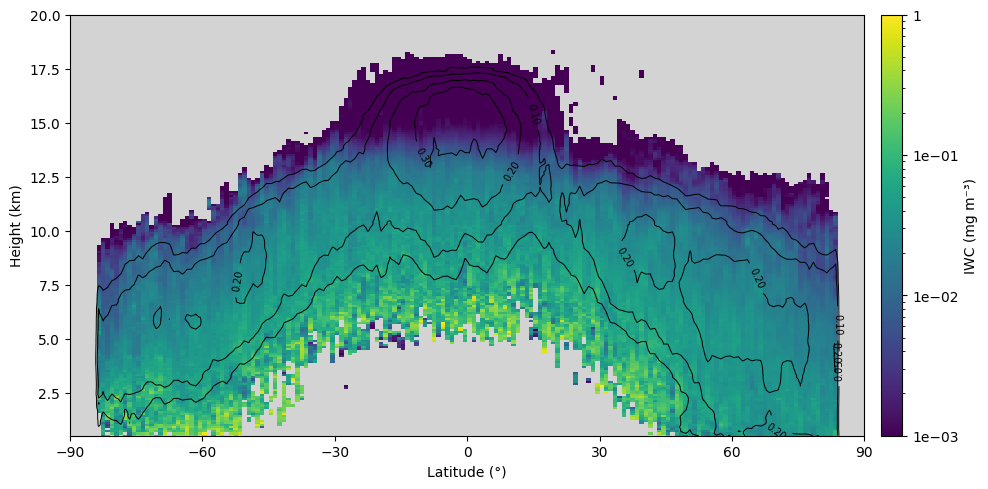

In [48]:
cross_section(
    iwc,
    title="",
    cbar_label="IWC (mg m⁻³)",
    cmap="viridis",
    log_scale=True,
    vmin=1e-3,
    vmax=1.0,
    fname="M1v2_iwc_latheight.png",
)

In [49]:
weighted_stats(iwc, ice_n, "IWC (mg m⁻³)")

  IWC (mg m⁻³)
    n cells       : 19,730   total pixels : 25,157,462
    min / max     : 8.027e-06 / 0.9882
    w.mean / w.std: 0.02409 / 0.01972
    p5/p25/p50/p75/p95: 0.0005783 / 0.01083 / 0.02229 / 0.03428 / 0.05216



## Figure M2v2 — Ice Crystal Effective Radius

Saved M2v2_reff_latheight.png


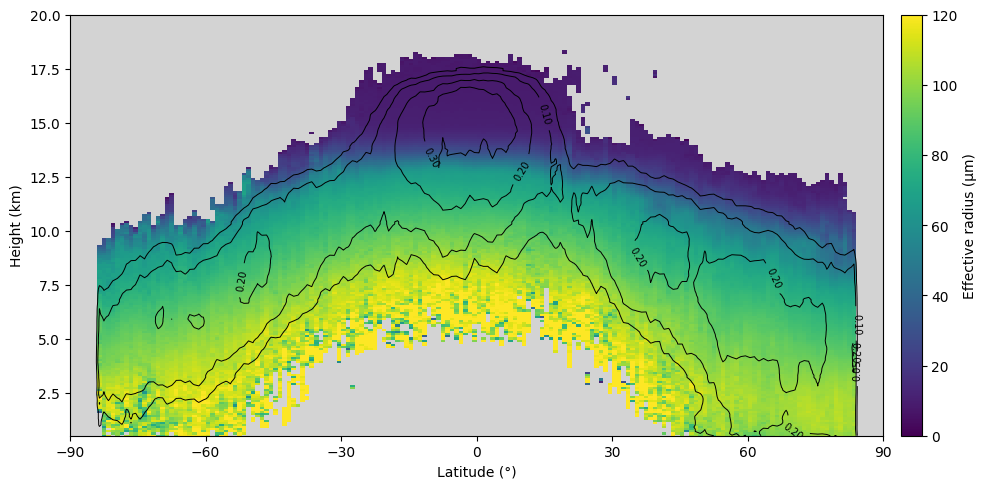

In [50]:
cross_section(
    reff,
    title="",
    cbar_label="Effective radius (μm)",
    cmap="viridis",
    log_scale=False,
    vmin=0,
    vmax=120,
    cbar_ticks=list(range(0, 121, 20)),
    fname="M2v2_reff_latheight.png",
)

In [51]:
weighted_stats(reff, ice_n, "Effective radius (μm)")

  Effective radius (μm)
    n cells       : 19,730   total pixels : 25,157,462
    min / max     : 0.7206 / 153.9
    w.mean / w.std: 70.26 / 29.59
    p5/p25/p50/p75/p95: 9.835 / 57.72 / 78.19 / 92.08 / 104.8



## Figure M_profiles_v2 — Vertical profiles by latitude band

Zonal-mean profiles of IWC and r_eff for three latitude bands.
Shading shows ±1 std of cell-mean values across the latitude band.

/var/folders/vp/b00pzthx34g6lmnpx9qphb5h0000gn/T/ipykernel_42559/3770236120.py:17: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(sub, axis=0)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Saved M_profiles_v2_microphysics.png


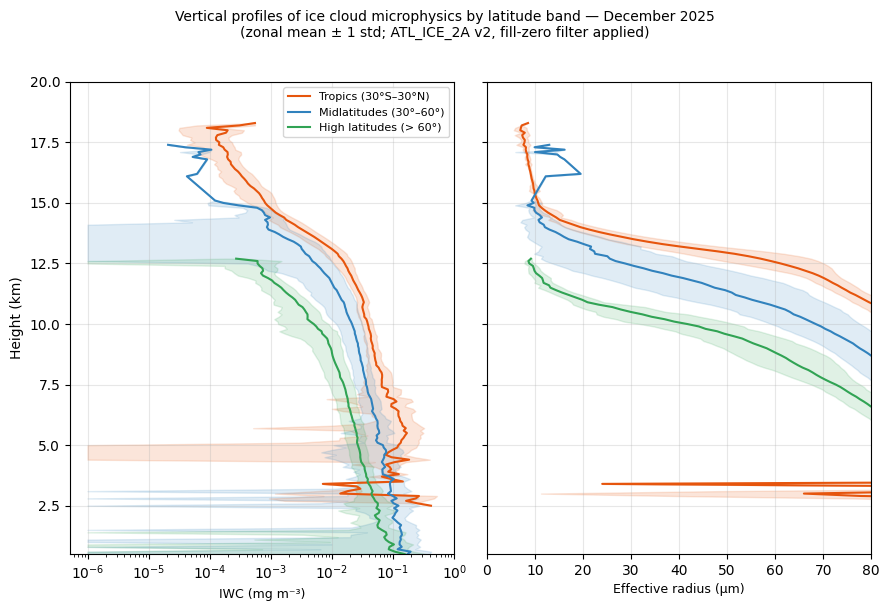

In [52]:
BANDS = [
    ("Tropics (30°S–30°N)",      np.abs(lat) <= 30,                             "#e6550d"),
    ("Midlatitudes (30°–60°)",   (np.abs(lat) > 30) & (np.abs(lat) <= 60),      "#3182bd"),
    ("High latitudes (> 60°)",   np.abs(lat) > 60,                              "#31a354"),
]

panels = [
    (iwc,  "IWC (mg m⁻³)",         True,  None, None),
    (reff, "Effective radius (μm)", False, 0,    80),
]

fig, axes = plt.subplots(1, 2, figsize=(9, 6), sharey=True)

for ax, (data, xlabel, use_log, xmin, xmax) in zip(axes, panels):
    for label, mask, color in BANDS:
        sub  = data[mask, :]          # (n_lat_in_band, n_heights)
        mean = np.nanmean(sub, axis=0)
        std  = np.nanstd(sub,  axis=0)
        valid = np.isfinite(mean)

        if use_log:
            pos = valid & (mean > 0)
            ax.semilogx(mean[pos], h_plot[pos], color=color, linewidth=1.5, label=label)
            ax.fill_betweenx(h_plot[pos],
                             np.maximum(mean[pos] - std[pos], 1e-6),
                             mean[pos] + std[pos],
                             color=color, alpha=0.15)
        else:
            ax.plot(mean[valid], h_plot[valid], color=color, linewidth=1.5, label=label)
            ax.fill_betweenx(h_plot[valid],
                             mean[valid] - std[valid],
                             mean[valid] + std[valid],
                             color=color, alpha=0.15)

    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylim(H_MIN_KM, H_MAX_KM)
    ax.grid(True, alpha=0.3)
    if xmin is not None: ax.set_xlim(left=xmin)
    if xmax is not None: ax.set_xlim(right=xmax)

axes[0].set_ylabel("Height (km)", fontsize=10)
axes[0].legend(fontsize=8, loc="upper right", framealpha=0.8)

fig.suptitle(
    "Vertical profiles of ice cloud microphysics by latitude band — December 2025\n"
    "(zonal mean ± 1 std; ATL_ICE_2A v2, fill-zero filter applied)",
    fontsize=10, y=1.01,
)
plt.tight_layout()
plt.savefig(OUT_DIR / "M_profiles_v2_microphysics.png", dpi=300, bbox_inches="tight")
print("Saved M_profiles_v2_microphysics.png")
plt.show()